# Creation of Synthetic Neural Responses

### Synthetic Neural Responses

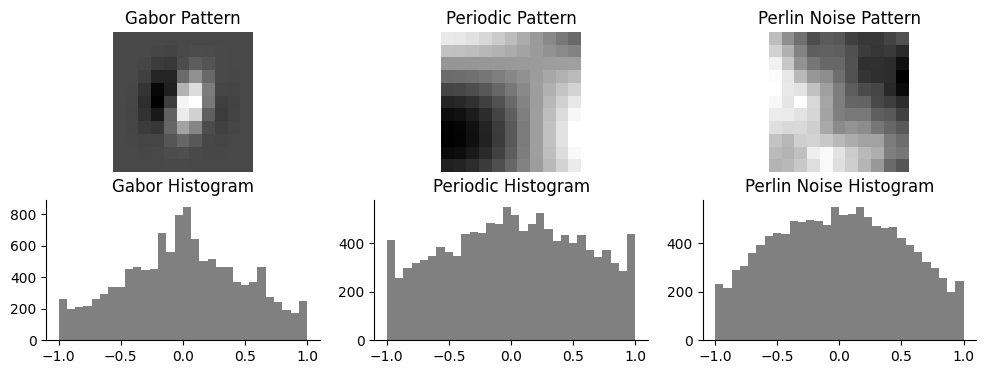

Gabor Pattern: mean=0.0063, std=0.4785
Periodic Pattern: mean=0.0181, std=0.5439
Perlin Noise Pattern: mean=-0.0083, std=0.5078


In [1]:
# Example patterns
from neurodecoders.synthetic.sta import STA
import matplotlib.pyplot as plt
import numpy as np


gabor = STA().get_simulated_sta(type="gabor,11,11", length=100)
periodic_pattern = STA().get_simulated_sta(type="periodic_patterns,11,11", length=100)
perlin_noise_pattern = STA().get_simulated_sta(type="perlin_noise_patterns,11,11", length=100)

fig, axs = plt.subplots(2, 3, figsize=(12, 4))
axs[0, 0].imshow(gabor[0], cmap='gray')
axs[0, 0].set_title('Gabor Pattern')
axs[0, 1].imshow(periodic_pattern[0], cmap='gray')
axs[0, 1].set_title('Periodic Pattern')
axs[0, 2].imshow(perlin_noise_pattern[0], cmap='gray')
axs[0, 2].set_title('Perlin Noise Pattern')
#  no axes for the images
for ax in axs[0]:   
    ax.axis('off')

#  now histograms
axs[1, 0].hist(gabor.flatten(), bins=30, color='gray')
axs[1, 0].set_title('Gabor Histogram')
axs[1, 1].hist(periodic_pattern.flatten(), bins=30, color='gray')
axs[1, 1].set_title('Periodic Histogram')
axs[1, 2].hist(perlin_noise_pattern.flatten(), bins=30, color='gray')
axs[1, 2].set_title('Perlin Noise Histogram')

#  remove top and right spines for histograms
for ax in axs[1]:   
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.show()  

#  print mean and std of each pattern
print(f'Gabor Pattern: mean={np.mean(gabor):.4f}, std={np.std(gabor):.4f}')
print(f'Periodic Pattern: mean={np.mean(periodic_pattern):.4f}, std={np.std(periodic_pattern):.4f}')
print(f'Perlin Noise Pattern: mean={np.mean(perlin_noise_pattern):.4f}, std={np.std(perlin_noise_pattern):.4f}')

Calculated normalization stats: mean=0.4803, std=0.2392


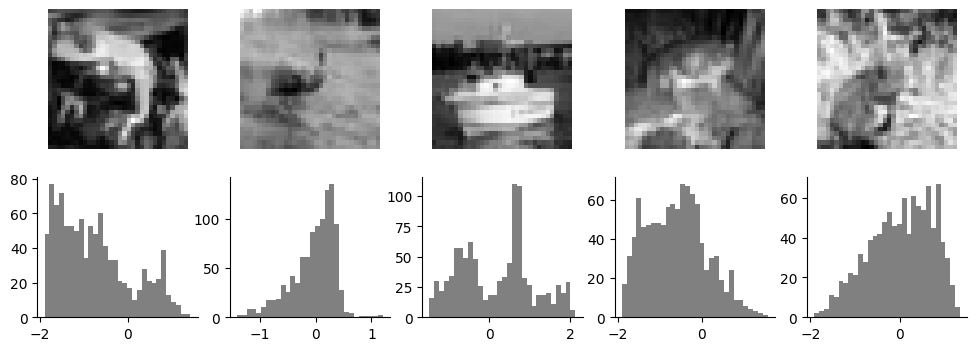

CIFAR10: mean=-0.0529, std=0.9732
CIFAR10: mean_min=-1.7392, mean_max=1.7286


In [2]:
# look at cifar10 statistics
from neurodecoders.synthetic.image_datasets import ImageDataset
images, labes = ImageDataset().get_data(type='cifar10', n_images=100)

#  remove empty axis
cifar10 = images.squeeze()

#  plot a few cifar10 images and their histograms
fig, axs = plt.subplots(2, 5, figsize=(12, 4))
for i in range(5):
    axs[0, i].imshow(cifar10[i], cmap='gray')
    axs[0, i].axis('off')
    axs[1, i].hist(cifar10[i].flatten(), bins=30, color='gray')
    axs[1, i].spines['top'].set_visible(False)
    axs[1, i].spines['right'].set_visible(False)
    # axs[1, i].set_xlim([-1, 1])
plt.show()

#  print mean and std of cifar10
print(f'CIFAR10: mean={cifar10.mean():.4f}, std={cifar10.std():.4f}')
#  print mean min and max
min_for_every_image = [cifar10[i].min() for i in range(cifar10.shape[0])]
max_for_every_image = [cifar10[i].max() for i in range(cifar10.shape[0])]
print(f'CIFAR10: mean_min={np.mean(min_for_every_image):.4f}, mean_max={np.mean(max_for_every_image):.4f}')

Images shape: torch.Size([100, 1, 32, 32])
Gabor STAs shape: (100, 11, 11)
Image dimensions: 32x32
Small Gabor STAs shape: (100, 11, 11)
Preparing data for batch computation...
Processing 10 neurons in 1 batches of up to 1000 neurons
Processing 100 images in 1 batches of up to 100 images


Processing image batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing image batches: 100%|██████████| 1/1 [00:00<00:00, 19.73it/s]

Dot Products: min=-45.8844, max=43.4088
Thresholded Dot Products: min=0.0000, max=43.4088
Gaussian Noise: min=-2.8040, max=3.8313
Final Firing Rates: min=0.0000, max=102.1868


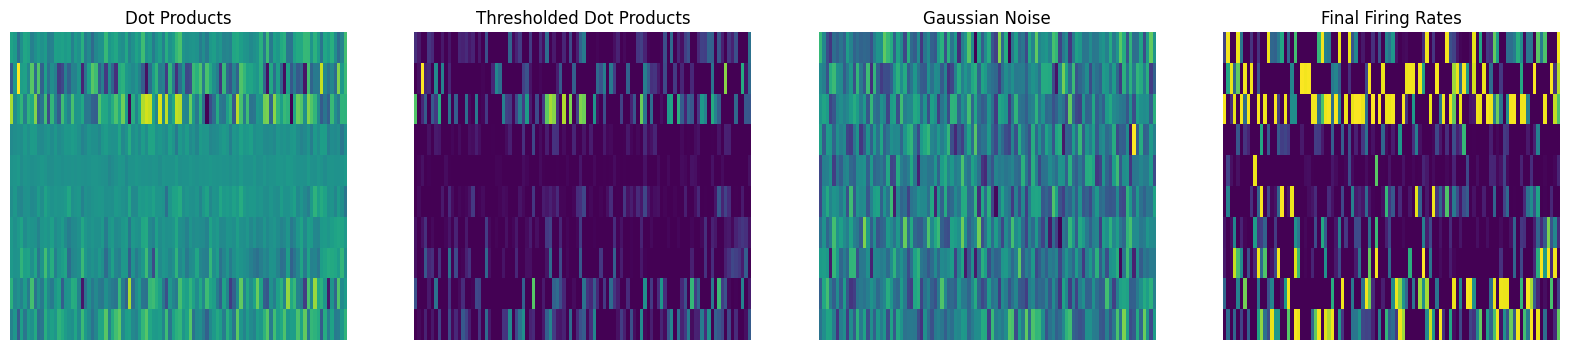

In [3]:
from neurodecoders.synthetic.simulate_response import SimulateResponse

# Check image dimensions
print(f"Images shape: {images.shape}")
print(f"Gabor STAs shape: {gabor.shape}")

# Extract image dimensions
image_height, image_width = images.shape[-2:]
print(f"Image dimensions: {image_height}x{image_width}")

# Create smaller Gabor patterns that fit the 32x32 images
# Let's use 16x16 STAs (half the image size to allow for RF placement)
gabor_small = STA().get_simulated_sta(type="gabor,11,11", length=100)
print(f"Small Gabor STAs shape: {gabor_small.shape}")

simulator = SimulateResponse(
    device="cpu",
    images_or_loader_fn=images,
    stas=gabor_small,
    n_neurons=10,
    image_height=image_height,
    image_width=image_width)

firing_rates, dot_products, noises = simulator.simulate_neural_responses_vectorized()

fig, ax = plt.subplots(1, 4, figsize=(20, 4))

ax[0].imshow(dot_products.T, aspect='auto', cmap='viridis')
ax[0].set_title('Dot Products')
#  print min and max of dot products
print(f'Dot Products: min={dot_products.min():.4f}, max={dot_products.max():.4f}')

ax[1].imshow(dot_products.T, aspect='auto', cmap='viridis', vmin=0)
ax[1].set_title('Thresholded Dot Products')
print(f'Thresholded Dot Products: min={np.clip(dot_products, 0, None).min():.4f}, max={np.clip(dot_products, 0, None).max():.4f}')

ax[2].imshow(noises.T, aspect='auto', cmap='viridis')
ax[2].set_title('Gaussian Noise')
print(f'Gaussian Noise: min={noises.min():.4f}, max={noises.max():.4f}')

im = ax[3].imshow(firing_rates.T, aspect='auto', cmap='viridis')
ax[3].set_title('Final Firing Rates')
print(f'Final Firing Rates: min={firing_rates.min():.4f}, max={firing_rates.max():.4f}')

#  axis off
for a in ax:
    a.axis('off')

#  add y and x label only for first subplot
ax[0].set_ylabel('Neurons')
ax[0].set_xlabel('Images')

plt.show()

In [4]:
# Load generated datasets
from pathlib import Path

path_to_main_folder = Path("/ceph/margrie/laura/neurodecoders")
path_to_workspace = path_to_main_folder / "workspace"
path_to_synthetic_data = path_to_workspace / "datasets" / "synthetic" / "train" 

all_datasets = list(path_to_synthetic_data.glob("*.npz"))
datasets = []
for dataset in all_datasets:
    if "gabor" in dataset.name:
        print(dataset.name)
        datasets.append(dataset)


synthdata_dataset-cifar10_sta-gabor,100,100_n_neurons-10_n_images-80_split-train_datetime-20250905_143530.npz
synthdata_dataset-cifar10_sta-gabor,11,11_n_neurons-10_n_images-80_split-train_datetime-20251105_171300.npz
synthdata_dataset-cifar10_sta-gabor,100,100_n_neurons-100_n_images-8000_split-train_datetime-20250905_145903.npz
synthdata_dataset-cifar10_sta-gabor,11,11_n_neurons-5000_n_images-8000_split-train_datetime-20251105_170143.npz
synthdata_dataset-cifar10_sta-gabor,100,100_n_neurons-5000_n_images-8000_split-train_datetime-20251104_161925.npz
synthdata_dataset-cifar10_sta-gabor,70,70_n_neurons-100_n_images-8000_split-train_datetime-20250918_144945.npz
synthdata_dataset-cifar10_sta-gabor,11,11_n_neurons-5000_n_images-8000_split-train_datetime-20251104_201752.npz
synthdata_dataset-mnist_sta-gabor,100,100_n_neurons-100_n_images-8000_split-train_datetime-20250919_140150.npz


In [6]:
# let's look at the small dataset and see what there is inside
import numpy as np

small_dataset_path = datasets[1]
data = np.load(small_dataset_path)
data.files

['images', 'responses', 'stas', 'rf_coords', 'adaptation_states', 'labels']

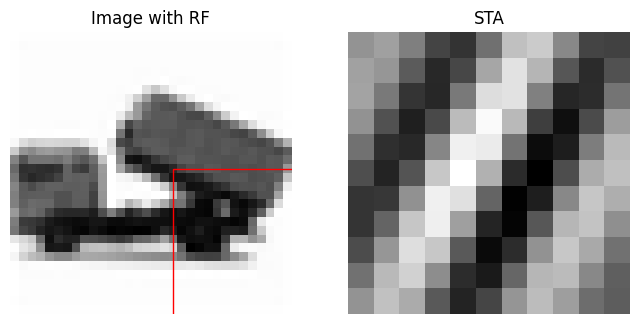

Firing rate for the first neuron and first image: 17.99 Hz


In [7]:
# Let's plot one example of image and STA and also a bounding box of the 70x70 RF
import matplotlib.pyplot as plt

image = data["images"][0][0, :, :]  # first image, first channel
sta = data["stas"][0]
rf_coords = data["rf_coords"][0]

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(image, cmap="gray")
rect = plt.Rectangle(
    (rf_coords[0], rf_coords[1]), 70, 70, linewidth=1, edgecolor="r", facecolor="none"
)
ax[0].add_patch(rect)   
ax[0].set_title("Image with RF")
ax[1].imshow(sta, cmap="gray")
ax[1].set_title("STA")
ax[0].axis("off")
ax[1].axis("off")
plt.show()

#  let's also print the firing rate for this neuron and this image
firing_rate = data["responses"][0][0]  # first neuron, first image
print(f"Firing rate for the first neuron and first image: {firing_rate:.2f} Hz")

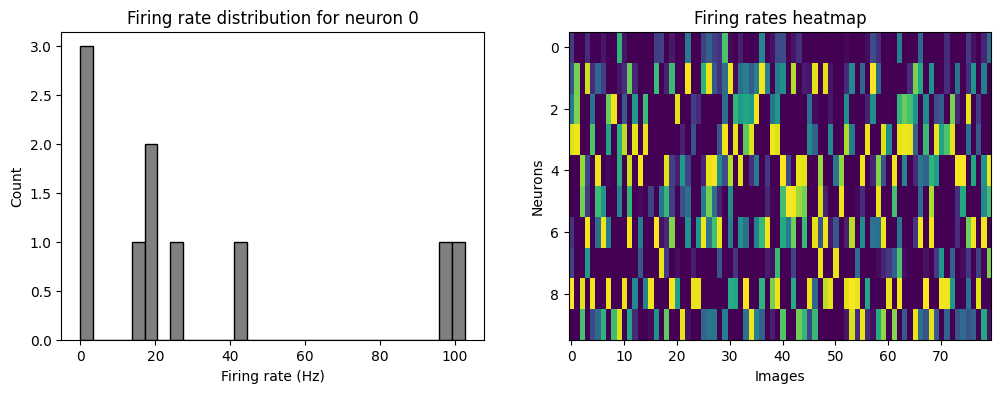

In [8]:
# plot the distribution of firing rates for this neuron

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(data["responses"][0], bins=30, color="gray", edgecolor="black")
ax[0].set_title("Firing rate distribution for neuron 0")
ax[0].set_xlabel("Firing rate (Hz)")
ax[0].set_ylabel("Count")
ax[1].imshow(data["responses"].T, aspect="auto", cmap="viridis")
ax[1].set_title("Firing rates heatmap")
ax[1].set_xlabel("Images")
ax[1].set_ylabel("Neurons")
plt.show()


In [14]:
# let's look at the big dataset and create z-scored neuron average images 
# to see if they look like the STA
import numpy as np
from neurodecoders.synthetic.create_zscored_neuron_averages import (
    create_zscore_neuron_average_images,
)

big_dataset_path = datasets[3]
big_data = np.load(big_dataset_path)

In [21]:
average_images_zscore = create_zscore_neuron_average_images(
        big_data["images"], big_data["responses"], n_neurons=2
    )

Creating z-score normalized average images for 2 neurons...


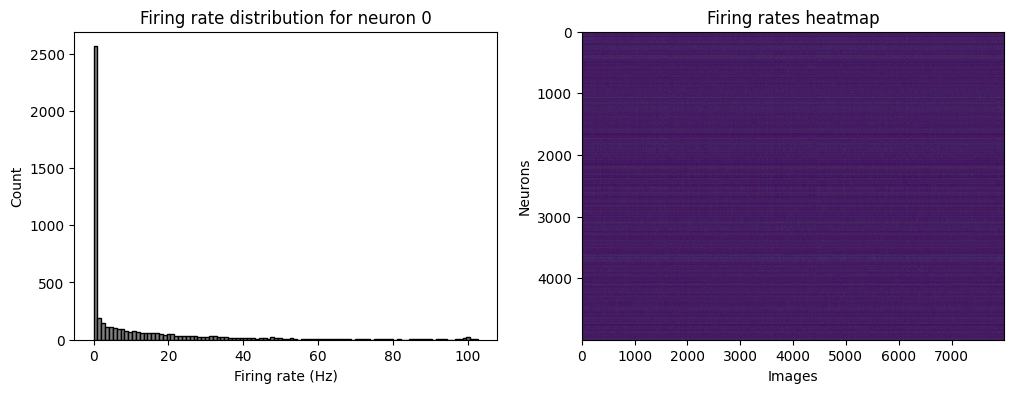

In [22]:
# plot the distribution of firing rates for this neuron
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(big_data["responses"][0], bins=100, color="gray", edgecolor="black")
ax[0].set_title("Firing rate distribution for neuron 0")
ax[0].set_xlabel("Firing rate (Hz)")
ax[0].set_ylabel("Count")
ax[1].imshow(big_data["responses"].T, aspect="auto", cmap="viridis")
ax[1].set_title("Firing rates heatmap")
ax[1].set_xlabel("Images")
ax[1].set_ylabel("Neurons")
plt.show()



11
[ 8 15]
(32, 32)


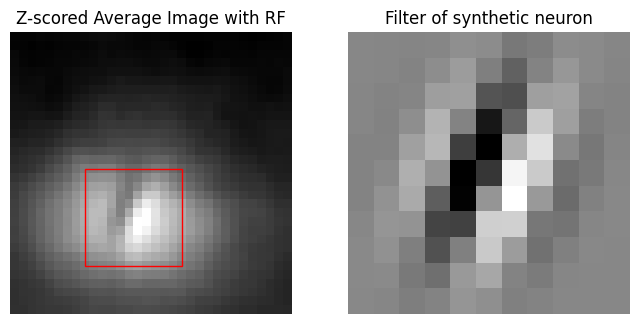

In [24]:
neuron_id = 1

#  plot the z-scored average image and the patch bounding box
sta = big_data["stas"][neuron_id]
sta_shape = sta.shape[0]
print(sta_shape)
rf_coords = big_data["rf_coords"][neuron_id]
print(rf_coords)
zscore_image = average_images_zscore[neuron_id][0, :, :]  
print(zscore_image.shape)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(zscore_image, cmap="gray")
rect = plt.Rectangle(
    (rf_coords[0], rf_coords[1]), sta_shape, sta_shape, linewidth=1, edgecolor="r", facecolor="none"
)
ax[0].add_patch(rect)
ax[0].set_title("Z-scored Average Image with RF")
ax[1].imshow(sta, cmap="gray")
ax[1].set_title("Filter of synthetic neuron")
ax[0].axis("off")
ax[1].axis("off")
plt.show()


IndexError: index 10 is out of bounds for axis 0 with size 10

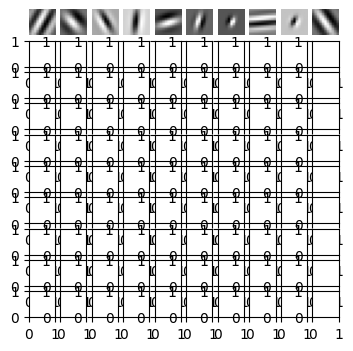

In [ ]:
stas = big_data["stas"]

# plot the STA
fig, ax = plt.subplots(10, 10, figsize=(4, 4))
for i in range(10):
    for j in range(10):
        neuron_id = i * 10 + j
        ax[i, j].imshow(stas[neuron_id], cmap="gray")
        ax[i, j].axis("off")
plt.suptitle("STAs for 100 neurons")
plt.show()


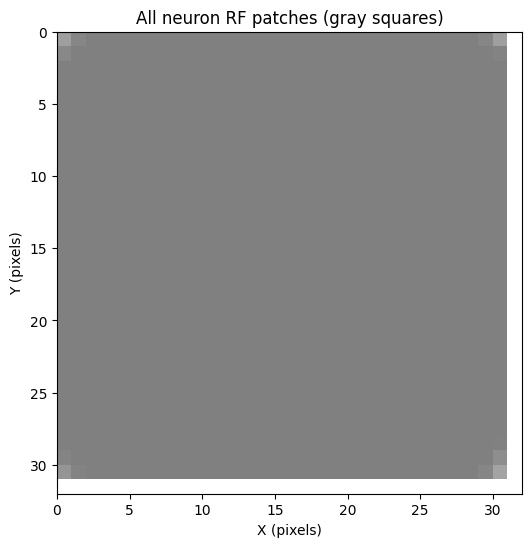

In [17]:
# Plot all neuron RF patches as gray squares to visualize coverage
import matplotlib.pyplot as plt

image_shape = big_data["images"].shape[-2:]  # (height, width)
rf_coords = big_data["rf_coords"]
sta_shapes = [sta.shape[0] for sta in big_data["stas"]]

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim([0, image_shape[1]])
ax.set_ylim([0, image_shape[0]])
ax.invert_yaxis()  # To match image coordinates

for i, (coord, size) in enumerate(zip(rf_coords, sta_shapes)):
    rect = plt.Rectangle((coord[0], coord[1]), size, size, linewidth=0, edgecolor=None, facecolor="gray", alpha=0.1)
    ax.add_patch(rect)

ax.set_title("All neuron RF patches (gray squares)")
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
plt.show()